<a href="https://colab.research.google.com/github/sandip-1996/PRML_exercise_code_example/blob/Probability-distribution-ch.-2/Von_mises_distribution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

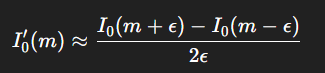

theta_ML : 1.5890087112203106
m_ML : 0.01


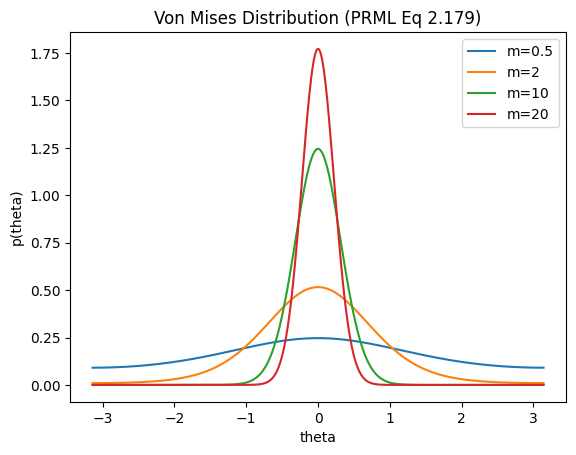

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import factorial

# ---- Bessel function I0 using series expansion ----
def I0(m, terms=50):
    result = 0.0
    for k in range(terms):
        term = (1 / (factorial(k,exact = True))**2) * (m/2)**(2*k)
        result += term
    return result


# ---- von Mises PDF ----
def von_mises_pdf(theta, theta0, m):
    return np.exp(m * np.cos(theta - theta0)) / (2 * np.pi * I0(m))

# max likelihood
def estimate_theta0(theta_data):
    C = np.mean(np.cos(theta_data))
    S = np.mean(np.sin(theta_data))
    return np.arctan2(S, C)


def A_of_m(m):
    # approximate using Bessel functions
    # I1 approx (simple finite difference)
    ''' A(m) = I1(m)/I0(m) = I0'(m)/I0(m)'''
    epsilon = 1e-5
    return (I0(m + epsilon) - I0(m - epsilon)) / (2 * epsilon * I0(m))


def estimate_m(theta_data):
    theta0 = estimate_theta0(theta_data)
    R = np.mean(np.cos(theta_data - theta0))

    # solve A(m) = R (simple search)
    m_vals = np.linspace(0.01, 20, 500)
    errors = [abs(A_of_m(m) - R) for m in m_vals]
    return m_vals[np.argmin(errors)]

''' here we check model concentration = data concentration, the more close the value of two we take that m value as m_ML'''

# ---- Generate theta values ----
theta = np.linspace(-np.pi, np.pi, 500)
''' we can took 0 to pi or 0 to 2pi that's completely normal but mean appears at boundary it is slightly awkward.
'''

# ---- Parameters ----
theta0 = 0.0   # mean direction take mean = 0
m_values = [0.5, 2, 10, 20]  # concentration m = r/sigma^2 as per book

theta_ML = estimate_theta0([1,3,20,52,90,175])
m_ML = estimate_m(theta)

print("theta_ML :", theta_ML)
print("m_ML :", m_ML)

# ---- Plot ----
plt.figure()

for m in m_values:
    p = von_mises_pdf(theta, theta0, m)
    plt.plot(theta, p, label=f"m={m}")

plt.title("Von Mises Distribution (PRML Eq 2.179)")
plt.xlabel("theta")
plt.ylabel("p(theta)")
plt.legend()
plt.show()

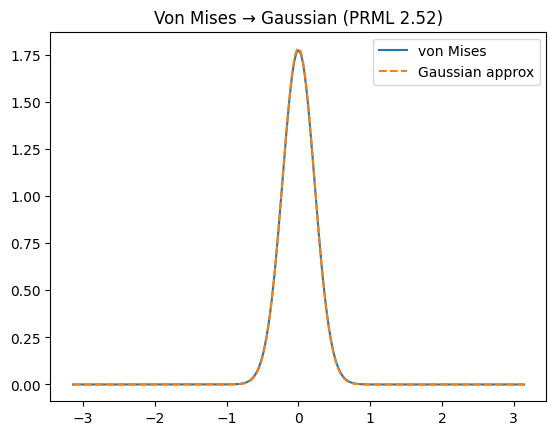

In [45]:
def gaussian(theta, mu, sigma):
    return (1 / np.sqrt(2*np.pi*sigma**2)) * np.exp(-(theta-mu)**2 / (2*sigma**2))


m = 20
sigma = 1 / np.sqrt(m)

vm = von_mises_pdf(theta, 0, m)
gauss = gaussian(theta, 0, sigma)

plt.figure()
plt.plot(theta, vm, label="von Mises")
plt.plot(theta, gauss, '--', label="Gaussian approx")
plt.legend()
plt.title("Von Mises → Gaussian (PRML 2.52)")
plt.show()

estimated theta 1.0227874415566953
estimated_m 2.3334869739478954
true theta 1.0471975511965976
True m 2.5


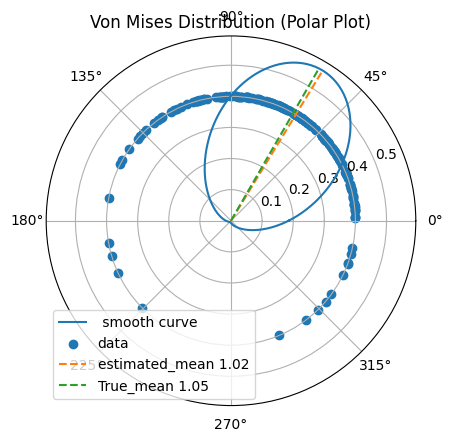

In [51]:
# von mises on polar plot

import numpy as np
import matplotlib.pyplot as plt
import math

def I0(m, terms=50):
    result = 0.0
    for k in range(terms):
        result += (1 / (math.factorial(k)**2)) * (m/2)**(2*k)
    return result

def von_mises_pdf(theta, theta0, m):
    return np.exp(m * np.cos(theta - theta0)) / (2 * np.pi * I0(m))

# generate synthetic data
Truetheta0 = np.pi/3
Truem = 2.5

theta_data = np.random.vonmises(Truetheta0, kappa = Truem, size = 200)


# estimate theta parameters
theta0_hat = estimate_theta0(theta_data)
m_hat = estimate_m(theta_data)
''' this is totally wrong we cannot calculate pdf_data using sample data because it is points not function.
pdf_data = von_mises_pdf(theta_data, theta0_hat, m_hat)
r_data = von_mises_pdf(theta_data, theta0_hat, m_hat)
we should plot this points using scatter plot '''



# parameters for smooth curve
theta = np.linspace(0, 2*np.pi, 500)
theta0 = theta0_hat
m_values = m_hat
pdf_smooth = von_mises_pdf(theta, theta0, m_values)


# print parameters
print("estimated theta", theta0_hat)
print("estimated_m", m_hat)
print("true theta", Truetheta0)
print("True m", Truem)


plt.figure()
ax = plt.subplot(111, projection='polar')
''' 111 means 1 row, 1 column, 1 plot '''

ax.plot(theta, pdf_smooth, label = " smooth curve")
ax.scatter(theta_data, np.ones_like(theta_data)*.4, label = "data")
# ax.scatter(theta_data, r_data)
ax.plot([theta0_hat, theta0_hat],[0,max(pdf_smooth)], linestyle = "--", label = f"estimated_mean {theta0_hat:.2f}")
ax.plot([Truetheta0, Truetheta0],[0,max(pdf_smooth)], linestyle = "--", label = f"True_mean {Truetheta0 :.2f}")
ax.set_title("Von Mises Distribution (Polar Plot)")
ax.legend()

plt.show()